# Load in Data

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd

# Load features
features_df = pd.read_csv('../output/features.csv', index_col=0)

print(f'Total consumers: {features_df.shape[0]}')
print(f'Delinquency rate: {features_df["DQ_TARGET"].mean():.2%}')

Total consumers: 10317
Delinquency rate: 8.86%


# Scoring Exclusion

In [2]:
import numpy as np
import pandas as pd

df_work = features_df.copy()
LABEL = "DQ_TARGET"

start_total   = len(df_work)
start_labeled = df_work[LABEL].notnull().sum()

# Accumulate boolean exclusion masks — all evaluated on the ORIGINAL df_work
exclusion_masks = {}

print("Starting total  :", start_total)
print("Starting labeled:", start_labeled)

Starting total  : 10317
Starting labeled: 10317


### Minimum History Days

In [3]:
MIN_DAYS = 20

exclusion_masks["rule_min_days"] = (
    (df_work["account__history_days__all"] < MIN_DAYS).fillna(True)
)

print(f"Rule 1 (account__history_days__all < {MIN_DAYS}): "
      f"{exclusion_masks['rule_min_days'].sum()} would be removed, about {exclusion_masks['rule_min_days'].sum()/features_df.shape[0]*100:.2f}% of the total population")

Rule 1 (account__history_days__all < 20): 519 would be removed, about 5.03% of the total population


### Minimum Total transactions

In [4]:
MIN_TX = 10

exclusion_masks["rule_min_tx"] = (
    (df_work["tx__n__all"] < MIN_TX).fillna(True)
)

print(f"Rule 2 (tx__n__all < {MIN_TX}): "
      f"{exclusion_masks['rule_min_tx'].sum()} would be removed, about {exclusion_masks['rule_min_tx'].sum()/features_df.shape[0]*100:.2f}% of the total population")

Rule 2 (tx__n__all < 10): 646 would be removed, about 6.26% of the total population


### Minimum Recent Transactions

In [5]:
# MIN_TX_30D = 5

# exclusion_masks["rule_min_tx30d"] = (
#     (df_work["n_tx__30d"] < MIN_TX_30D).fillna(True)
# )

# print(f"Rule 2 (n_tx__30d < {MIN_TX_30D}): "
#       f"{exclusion_masks['rule_min_tx30d'].sum()} would be removed, about {exclusion_masks['rule_min_tx30d'].sum()/features_df.shape[0]*100:.2f}% of the total population")

### Income Signal Present

In [6]:
MIN_INCOME_FREQ = 2/90

exclusion_masks["rule_income_presence"] = (
    (df_work["income__frequency__90d"] < MIN_INCOME_FREQ).fillna(True)
)

print(f"Rule 3 (income__frequency__90d < {MIN_INCOME_FREQ:.4f}): "
      f"{exclusion_masks['rule_income_presence'].sum()} would be removed, about {exclusion_masks['rule_income_presence'].sum()/features_df.shape[0]*100:.2f}% of the total population")

Rule 3 (income__frequency__90d < 0.0222): 612 would be removed, about 5.93% of the total population


In [7]:
# total percentage excluded by any rule
combined_mask = pd.concat(exclusion_masks.values(), axis=1).any(axis=1)
print(f"Total excluded by any rule: {combined_mask.sum()} would be removed, about {combined_mask.sum()/features_df.shape[0]*100:.2f}% of the total population")

Total excluded by any rule: 1065 would be removed, about 10.32% of the total population


### Credit transaction info present

In [8]:
# exclusion_masks["rule_has_credit"] = (
#     (df_work["tx__max_credit__all"] <= 0).fillna(True)
# )

# print(f"Rule 4 (tx__max_credit__all <= 0): "
#       f"{exclusion_masks['rule_has_credit'].sum()} would be removed")

In [9]:
# Combine all masks — a consumer is excluded if ANY rule flags them
combined_mask = pd.concat(exclusion_masks.values(), axis=1).any(axis=1)

# Apply once at the end
df_work = df_work.loc[~combined_mask].copy()

final_total   = len(df_work)
final_labeled = df_work[LABEL].notnull().sum()
total_removed = int(combined_mask.sum())

print("----- SUMMARY -----")
print(f"Started with : {start_total}")
print(f"Total removed: {total_removed}  ({total_removed/start_total:.1%} of original)")
print(f"Remaining    : {final_total}")
print()
print("Flagged by each rule (consumers may overlap):")
for rule, mask in exclusion_masks.items():
    print(f"  {rule}: {int(mask.sum())}")
print()
print(f"Labeled remaining: {final_labeled}")
print(f"Delinquency rate  : {df_work[LABEL].mean():.2%}")

----- SUMMARY -----
Started with : 10317
Total removed: 1065  (10.3% of original)
Remaining    : 9252

Flagged by each rule (consumers may overlap):
  rule_min_days: 519
  rule_min_tx: 646
  rule_income_presence: 612

Labeled remaining: 9252
Delinquency rate  : 8.67%


In [10]:
# save the final filtered dataset for modeling
df_work.to_csv('../output/filtered_features.csv', index=False)

# Data Splitting

In [11]:
from sklearn.model_selection import train_test_split
import numpy as np

LABEL = "DQ_TARGET"

df_clean = df_work[df_work[LABEL].notna()].copy()
X = df_clean.drop(columns=[LABEL]).fillna(0).values
y = df_clean[LABEL].astype(int).values

# 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train pos rate:", y_train.mean())
print("Val pos rate:", y_val.mean())
print("Test pos rate:", y_test.mean())

Train pos rate: 0.08665105386416862
Val pos rate: 0.08648648648648649
Test pos rate: 0.08698001080497028


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE: ", np.bincount(y_train_sm))

Before SMOTE: [5070  481]
After SMOTE:  [5070 5070]


In [16]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def metrics_df(model, X, y, split_name, model_name, train_time_sec):
     y_pred = model.predict(X)

     # ROC AUC requires probabilities
     y_prob = model.predict_proba(X)[:, 1]
     roc = roc_auc_score(y, y_prob)

     return pd.DataFrame({
         "model": [model_name],
         "split": [split_name],
         "accuracy": [accuracy_score(y, y_pred)],
         "roc_auc": [roc],
         "f1": [f1_score(y, y_pred, zero_division=0)],
         "train_time_sec": [train_time_sec],
     })

# Model Performance

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import numpy as np

_neg, _pos = (y_train == 0).sum(), (y_train == 1).sum()
_sw = np.where(y_train == 1, _neg / _pos, 1.0)

# Scaler for class-weight models (fit on original train)
_sc1 = StandardScaler()
_Xtr1 = _sc1.fit_transform(X_train)
_Xva1 = _sc1.transform(X_val)
_Xte1 = _sc1.transform(X_test)

# Scaler for SMOTE models (fit on SMOTE-resampled train)
_sc2 = StandardScaler()
_sc2.fit(X_train_sm)
_Xtr2     = _sc2.transform(X_train)    # original train — for fair eval
_Xva2     = _sc2.transform(X_val)
_Xte2     = _sc2.transform(X_test)
_Xtr2_sm  = _sc2.transform(X_train_sm) # SMOTE train — for fitting

# ── Logistic Regression (L2, lbfgs) ─────────────────────────────
_lr_cw = LogisticRegression(C=0.1, solver='lbfgs', max_iter=5000,
                             class_weight='balanced', random_state=42)
_lr_cw.fit(_Xtr1, y_train)

_lr_sm = LogisticRegression(C=0.1, solver='lbfgs', max_iter=5000, random_state=42)
_lr_sm.fit(_Xtr2_sm, y_train_sm)

# ── Gradient Boosting ────────────────────────────────────────────
_gbm_cw = GradientBoostingClassifier(n_estimators=400, max_depth=3, learning_rate=0.05,
                                      subsample=0.8, min_samples_leaf=40, random_state=42)
_gbm_cw.fit(X_train, y_train, sample_weight=_sw)

_gbm_sm = GradientBoostingClassifier(n_estimators=400, max_depth=3, learning_rate=0.05~,
                                      subsample=0.8, min_samples_leaf=40, random_state=42)
_gbm_sm.fit(X_train_sm, y_train_sm)

# ── Results (all evaluated on ORIGINAL, non-oversampled data) ────
print(f"{'Model':<32} {'Train AUC':>10} {'Val AUC':>10} {'Test AUC':>10}")
print("-" * 64)
for _name, _mdl, _Xtr_, _Xva_, _Xte_ in [
    ("LogReg  (class weight)",  _lr_cw,  _Xtr1,  _Xva1, _Xte1),
    ("LogReg  (SMOTE)",         _lr_sm,  _Xtr2,  _Xva2, _Xte2),
    ("GBM     (sample weight)", _gbm_cw, X_train, X_val, X_test),
    ("GBM     (SMOTE)",         _gbm_sm, X_train, X_val, X_test),
]:
    a = [roc_auc_score(y, _mdl.predict_proba(X)[:, 1])
         for y, X in [(y_train, _Xtr_), (y_val, _Xva_), (y_test, _Xte_)]]
    print(f"{_name:<32} {a[0]:>10.4f} {a[1]:>10.4f} {a[2]:>10.4f}")


Model                             Train AUC    Val AUC   Test AUC
----------------------------------------------------------------
LogReg  (class weight)               0.8282     0.7721     0.7856
LogReg  (SMOTE)                      0.8301     0.7747     0.7875
GBM     (sample weight)              0.9867     0.8166     0.7979
GBM     (SMOTE)                      0.9372     0.7890     0.7869


# Decision Tree

In [17]:
from sklearn.tree import DecisionTreeClassifier
import time

t0 = time.time()
dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=25,
    random_state=42
)
dt.fit(X_train_sm, y_train_sm)
dt_train_time = time.time() - t0

dt_results = pd.concat([
    metrics_df(dt, X_train, y_train, "train", "DecisionTree", dt_train_time),
    metrics_df(dt, X_val, y_val, "validation", "DecisionTree", dt_train_time),
    metrics_df(dt, X_test, y_test, "test", "DecisionTree", dt_train_time),
], ignore_index=True)

dt_results

,model,split,accuracy,roc_auc,f1,train_time_sec
0,DecisionTree,train,0.793190,0.798979,0.322314,1.236277
1,DecisionTree,validation,0.761622,0.723199,0.263773,1.236277
2,DecisionTree,test,0.764452,0.721403,0.258503,1.236277


# Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier
import time

t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_sm, y_train_sm)
rf_train_time = time.time() - t0

rf_results = pd.concat([
    metrics_df(rf, X_train, y_train, "train", "RandomForest", rf_train_time),
    metrics_df(rf, X_val, y_val, "validation", "RandomForest", rf_train_time),
    metrics_df(rf, X_test, y_test, "test", "RandomForest", rf_train_time),
], ignore_index=True)

rf_results

,model,split,accuracy,roc_auc,f1,train_time_sec
0,RandomForest,train,0.955504,0.965885,0.709069,6.032327
1,RandomForest,validation,0.878919,0.762703,0.258278,6.032327
2,RandomForest,test,0.881686,0.766970,0.242215,6.032327


In [19]:
all_results = pd.concat([dt_results, rf_results], ignore_index=True)
all_results = all_results.drop(columns=["train_time_sec"], errors="ignore")
all_results

,model,split,accuracy,roc_auc,f1
0,DecisionTree,train,0.793190,0.798979,0.322314
1,DecisionTree,validation,0.761622,0.723199,0.263773
2,DecisionTree,test,0.764452,0.721403,0.258503
3,RandomForest,train,0.955504,0.965885,0.709069
4,RandomForest,validation,0.878919,0.762703,0.258278
5,RandomForest,test,0.881686,0.766970,0.242215


In [20]:
import pandas as pd
import numpy as np

# Decision Tree baseline (fill these in)
dt_baseline = pd.DataFrame({
    "model": ["DecisionTree", "DecisionTree", "DecisionTree"],
    "split": ["train", "validation", "test"],
    "accuracy": [0.752, 0.721, 0.711],      
    "roc_auc": [0.69, 0.621, 0.629],       
    "f1": [0.24, 0.165, 0.164],            
    "train_time_sec": [2.51, 2.51, 2.51] 
})

# Random Forest baseline (your values)
rf_baseline = pd.DataFrame({
    "model": ["RandomForest", "RandomForest", "RandomForest"],
    "split": ["train", "validation", "test"],
    "accuracy": [0.96, 0.87, 0.88],
    "roc_auc": [0.9850, 0.7925, 0.7663],
    "f1": [0.79, 0.29, 0.29],
    "train_time_sec": [2.86, 2.86, 2.86]
})

baseline_results = pd.concat([dt_baseline, rf_baseline], ignore_index=True)
baseline_results = baseline_results.drop(columns=["train_time_sec"], errors="ignore")
baseline_results

,model,split,accuracy,roc_auc,f1
0,DecisionTree,train,0.752,0.6900,0.240
1,DecisionTree,validation,0.721,0.6210,0.165
2,DecisionTree,test,0.711,0.6290,0.164
3,RandomForest,train,0.960,0.9850,0.790
4,RandomForest,validation,0.870,0.7925,0.290
5,RandomForest,test,0.880,0.7663,0.290


## Reason Codes

In [41]:
from pathlib import Path

model = _lr_cw
beta  = model.coef_.ravel()

feature_names = df_clean.drop(columns=[LABEL]).columns.tolist()

X_holdout = _Xte1

# --------------------------
def prettify_reason(f: str) -> str:
    s = str(f).lower()

    # ---- Category features ----
    if "cat_" in s:
        return "High discretionary spending"

    # ---- History / activity ----
    if "history_days" in s or "account__history_days" in s:
        return "Short account history"

    if "n_days" in s:
        return "Limited account activity"

    if "n_tx" in s or "tx__n__all" in s or s.startswith("tx__n"):
        return "Low transaction activity"

    # ---- Balances ----
    if "pct_below" in s or "days_below" in s:
        return "Low account balances"

    if "negative" in s or "below_zero" in s or "pct_negative" in s:
        return "Frequent negative balances"

    if "min_before_income" in s:
        return "Balances run low before income deposits"

    # ---- Income ----
    if "income__frequency" in s or "paycheck__count" in s or "income__count" in s:
        return "Inconsistent income deposits"

    if "income__coefficient_of_variation" in s:
        return "Income deposits vary a lot"

    if "income__avg_days_between" in s:
        return "Income deposits are irregularly timed"

    # ---- Cashflow ----
    if "cashflow__volatility" in s:
        return "Highly variable cashflow"

    if "cashflow__net" in s:
        return "Low net cashflow"

    # ---- Fees / overdrafts ----
    if "overdraft" in s:
        return "Overdraft activity"

    if "fee" in s:
        return "Fee activity"

    return "Spending and activity patterns increased risk"

contrib = X_holdout * beta                           
contrib_df = pd.DataFrame(contrib, columns=feature_names)
contrib_pos = contrib_df.clip(lower=0)            

topk = 3
top_idx = np.argsort(-contrib_pos.values, axis=1)[:, :topk]
top_feats = [[contrib_pos.columns[j] for j in row] for row in top_idx]

reason_codes_df = pd.DataFrame(top_feats, columns=["reason_1", "reason_2", "reason_3"])
reason_codes_df = reason_codes_df.applymap(prettify_reason)

reason_codes_df["pred_risk"] = model.predict_proba(X_holdout)[:, 1]

reason_dist = pd.concat(
    [reason_codes_df["reason_1"], reason_codes_df["reason_2"], reason_codes_df["reason_3"]],
    axis=0
).value_counts()

print("\nTop 15 reason codes:")
display(reason_dist.head(15))
display(reason_codes_df.head(10))


Top 15 reason codes:


High discretionary spending                      1791
Limited account activity                         1533
Short account history                             724
Low account balances                              684
Low transaction activity                          281
Inconsistent income deposits                      123
Frequent negative balances                        119
Income deposits vary a lot                         94
Spending and activity patterns increased risk      79
Overdraft activity                                 40
Balances run low before income deposits            30
Highly variable cashflow                           18
Low net cashflow                                   16
Income deposits are irregularly timed              15
Fee activity                                        6
Name: count, dtype: int64

,reason_1,reason_2,reason_3,pred_risk
0,Short account history,Limited account activity,High discretionary spending,0.121464
1,Short account history,Limited account activity,High discretionary spending,0.565767
2,Limited account activity,Short account history,Low account balances,0.580016
3,Limited account activity,High discretionary spending,Low account balances,0.242792
4,Limited account activity,Income deposits are irregularly timed,High discretionary spending,0.386957
5,Limited account activity,High discretionary spending,High discretionary spending,0.296908
6,Short account history,High discretionary spending,Limited account activity,0.425662
7,High discretionary spending,Low transaction activity,Balances run low before income deposits,0.020972
8,Short account history,Limited account activity,High discretionary spending,0.459562
9,High discretionary spending,Low transaction activity,Limited account activity,0.138972


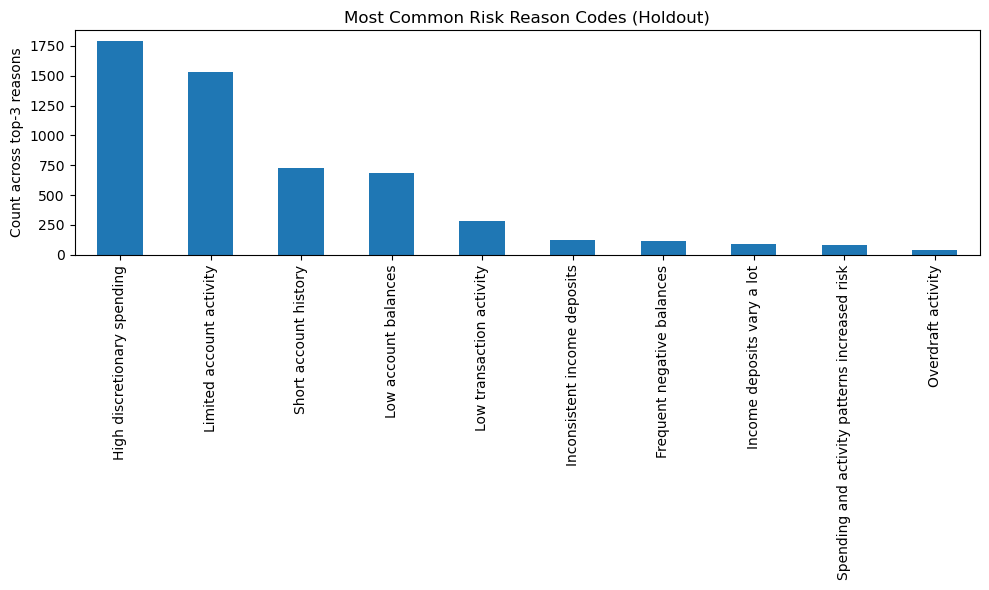

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

reason_dist.head(10).plot(kind="bar")
plt.title("Most Common Risk Reason Codes (Holdout)")
plt.ylabel("Count across top-3 reasons")
plt.tight_layout()
plt.show()

## Holdout

In [62]:
import pandas as pd
import numpy as np

features_path = Path("../feature_selection/features.csv")
features_df = pd.read_csv(features_path)

# =========================
# 1) Choose your final model (the one you already trained)
# =========================
model = _gbm_cw   # change to rf / etc. if needed

# =========================
# 2) Load holdout consumer list (THIS is the holdout to score)
# =========================
holdout = pd.read_parquet("/uss/hdsi-prismdata/q2-ucsd-consDF.pqt")
ids = holdout["prism_consumer_id"].astype(int).values
print("Holdout consumers:", len(ids))

# =========================
# 3) Make sure features_df is indexed by prism_consumer_id
# =========================
if "prism_consumer_id" in features_df.columns:
    feats_all = features_df.set_index("prism_consumer_id").copy()
else:
    feats_all = features_df.copy()

# force matching dtype
feats_all.index = pd.Index(feats_all.index).astype(int)

# remove duplicate consumer rows if any
feats_all = feats_all[~feats_all.index.duplicated(keep="first")]

# =========================
# 4) Build X_holdout from engineered features (NOT from holdout table)
# =========================
X_holdout_df = feats_all.reindex(ids)[feature_names].copy()

# remove credit score if it accidentally appears
for col in ["credit_score", "CREDIT_SCORE", "fico", "FICO"]:
    if col in X_holdout_df.columns:
        X_holdout_df = X_holdout_df.drop(columns=[col])
        feature_names = [f for f in feature_names if f != col]

# sanity check: are we matching IDs correctly?
all_missing = X_holdout_df.isna().all(axis=1).sum()

X_holdout = X_holdout_df.fillna(0).values

# sanity check: if this prints False, you're scoring all-zeros => same score for everyone
print("Any nonzero features in holdout?", (X_holdout != 0).any())

# =========================
# 5) Predict probabilities
# =========================
pred_score = model.predict_proba(X_holdout)[:, 1]
print("Pred score range:", float(pred_score.min()), "to", float(pred_score.max()))

# =========================
# 6) Reason codes (using your logistic regression contributions + prettify_reason)
# =========================
beta = _lr_cw.coef_.ravel()
X_holdout_scaled = _sc1.transform(X_holdout)

contrib = X_holdout_scaled * beta
contrib_df = pd.DataFrame(contrib, columns=feature_names)

contrib_pos = contrib_df.clip(lower=0)
topk = 3
top_idx = np.argsort(-contrib_pos.values, axis=1)[:, :topk]
top_feats = [[feature_names[j] for j in row] for row in top_idx]

reason_df = pd.DataFrame(top_feats, columns=["reason_1", "reason_2", "reason_3"])
reason_df = reason_df.applymap(prettify_reason)

# =========================
# 7) Final submission file (1 row per consumer in holdout)
# =========================
final_df = pd.concat(
    [
        pd.Series(ids, name="consumer_id"),
        pd.Series(pred_score, name="pred_score"),
        reason_df
    ],
    axis=1
)

final_df.to_csv("final_predictions.csv", index=False)
print(final_df.head())

Holdout consumers: 15000
Any nonzero features in holdout? True
Pred score range: 0.004030893403913328 to 0.9572748205883215
   consumer_id  pred_score                     reason_1  \
0            0    0.041735  High discretionary spending   
1            1    0.051758  High discretionary spending   
2            2    0.288571         Low account balances   
3            3    0.073224         Low account balances   
4            4    0.035643     Limited account activity   

                      reason_2                     reason_3  
0         Low account balances     Limited account activity  
1  High discretionary spending  High discretionary spending  
2         Low account balances         Low account balances  
3     Limited account activity     Limited account activity  
4  High discretionary spending  High discretionary spending  
